In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def load_results_table(results_dir, methods_list, use_coords, use_demographic, file_name="aggregated_results.json"):
    agg_list = []
    for method in methods_list:
        if use_demographic and use_coords:
            folder_name = f"{method}_coords_demographic_radiomics"
        elif use_demographic and not use_coords:
            folder_name = f"{method}_demographic_radiomics"
        elif not use_demographic and use_coords:
            folder_name = f"{method}_coords_radiomics"
        else:
            folder_name = f"{method}_radiomics"
        aggregated_result_dir = Path(results_dir)/folder_name / file_name
        df = pd.read_json(aggregated_result_dir)
        agg_list.append(df)
    final_df = pd.concat(agg_list, ignore_index=True)
    # final_df = final_df[['model', 'Accuracy_Mean', 'ROC_AUC_Mean']]
    display(final_df)
    print("Average across models:")
    display(pd.DataFrame(final_df.mean(numeric_only=True)).T)

# Data Statistics

In [4]:
import os
import json
import pandas as pd

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

In [5]:
data_root = "/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/new_dataset"
dataset_dicts = read_json(os.path.join(data_root, "dataset_directories.json"))
center_1 = dataset_dicts['Masih-SUV']
center_2 = dataset_dicts['Razavi-SUV']
combined_centers = center_1 + center_2

In [6]:
def change_to_df(center_data, center_name):
    agg_list = []
    for p_info in center_data:
        radiomics_dir = os.path.join(data_root, center_name, str(list(p_info.keys())[0]), "radiomics", 'radiomics_each_lesion.json')
        nodes_radiomics = read_json(radiomics_dir)
        info = dict(list(p_info.values())[0])
        info['lesion_count'] = len(nodes_radiomics)
        agg_list.append(info)

    center_df = pd.DataFrame(agg_list)
    center_df = center_df.rename(columns={"Gender(Male=0, Fmale:1)": "Gender(Male:0, Female:1)"})
    center_df = center_df.drop(columns=['Stage'])
    return center_df
center_1_df = change_to_df(center_1, center_name='Masih-SUV')
center_2_df = change_to_df(center_2, center_name='Razavi-SUV')
combined_centers_df = pd.concat([center_1_df, center_2_df], ignore_index=True)


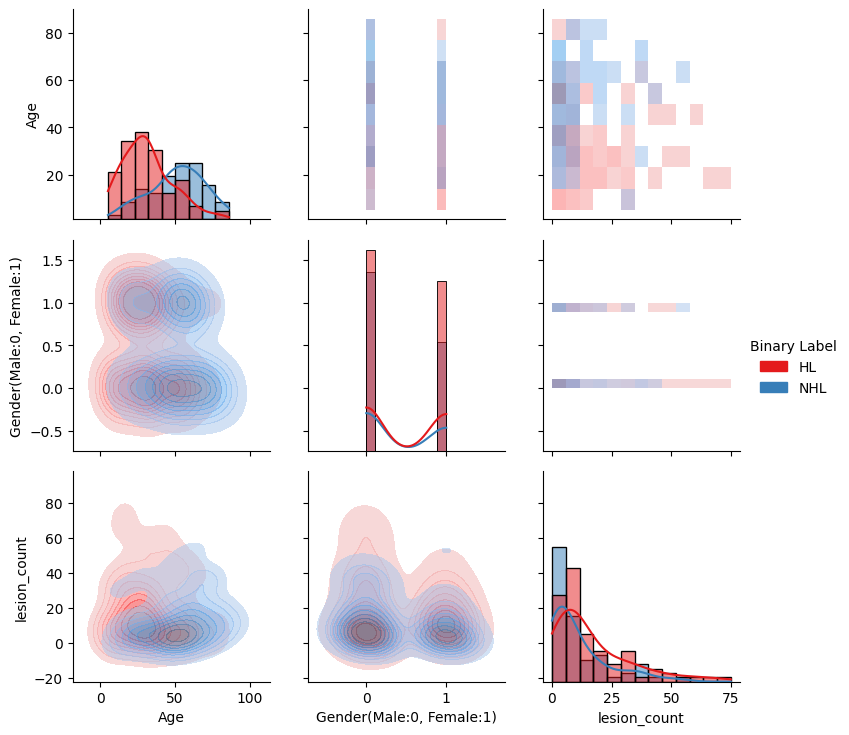

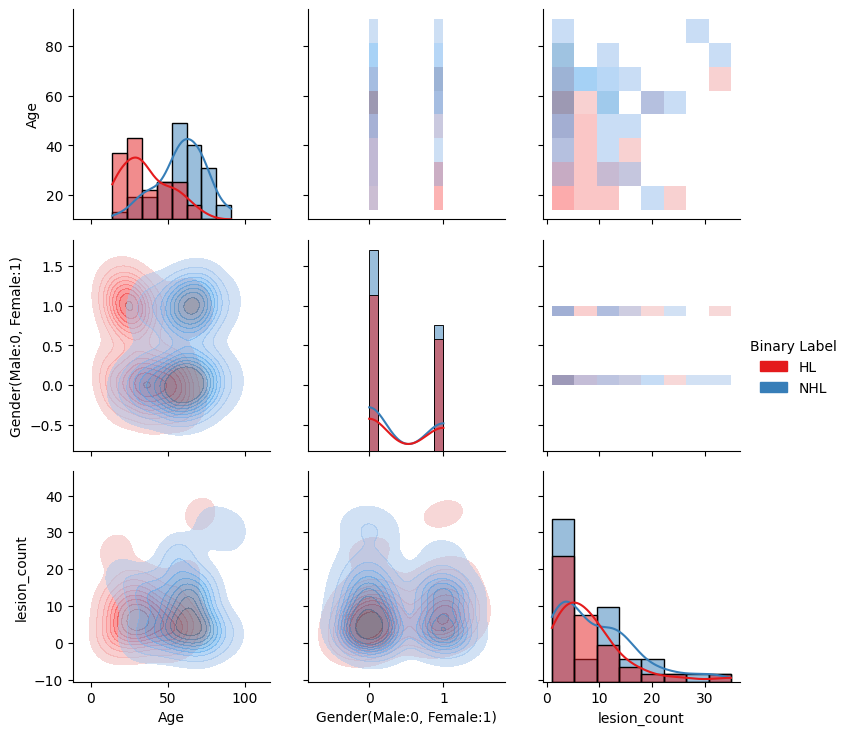

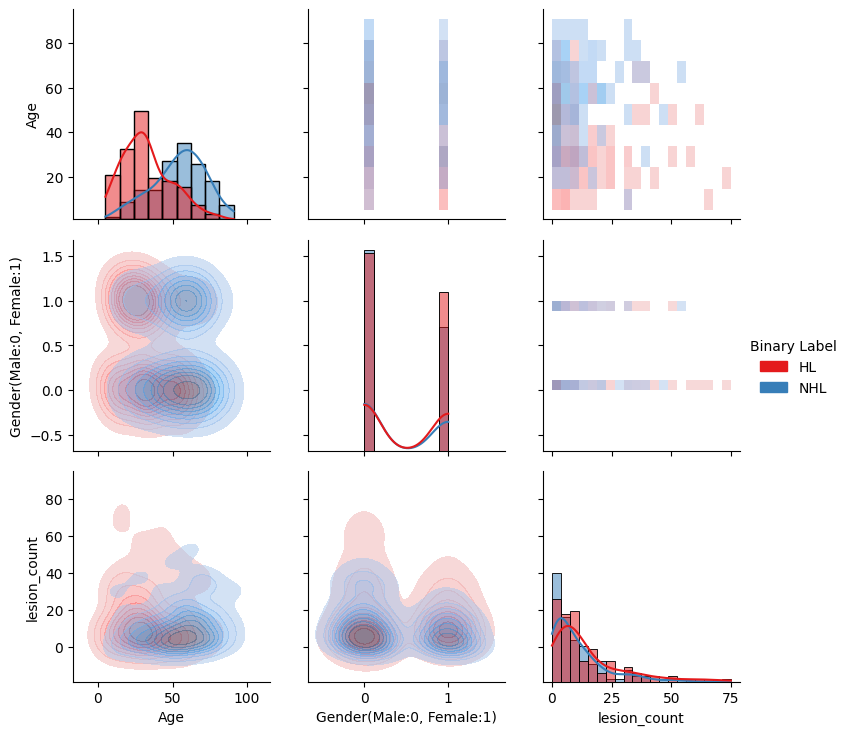

In [7]:
def plot_pairgrid(center_df):
    g = sns.PairGrid(data=center_df, hue="Binary Label", palette="Set1")
    g.map_upper(sns.histplot, alpha=0.5)
    g.map_lower(sns.kdeplot, fill=True, alpha=0.5)
    g.map_diag(sns.histplot, kde=True, alpha=0.5)
    g.add_legend()

plot_pairgrid(center_1_df)
plot_pairgrid(center_2_df)
plot_pairgrid(combined_centers_df)

In [8]:
def center_statistics(center_df, label):
    center_df = center_df.copy()
    center_df = center_df[center_df['Binary Label']==label]
    print(f"Gender distribution:")
    print(center_df['Gender(Male:0, Female:1)'].value_counts(normalize=False))
    print(center_df['Gender(Male:0, Female:1)'].value_counts(normalize=True))
    # age mean and std
    print("Age statistics:")
    print(center_df['Age'].describe())
    print("number of lesions statistics: ")
    print(center_df['lesion_count'].describe())


center_statistics(center_1_df, label='NHL')

Gender distribution:
Gender(Male:0, Female:1)
0    41
1    25
Name: count, dtype: int64
Gender(Male:0, Female:1)
0    0.621212
1    0.378788
Name: proportion, dtype: float64
Age statistics:
count    66.000000
mean     51.287879
std      18.238392
min      12.000000
25%      40.000000
50%      52.000000
75%      63.750000
max      86.000000
Name: Age, dtype: float64
number of lesions statistics: 
count    66.000000
mean     10.863636
std      12.241024
min       0.000000
25%       2.000000
50%       6.000000
75%      15.000000
max      53.000000
Name: lesion_count, dtype: float64


/tmp/ipykernel_2568541/813229708.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2568541/813229708.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


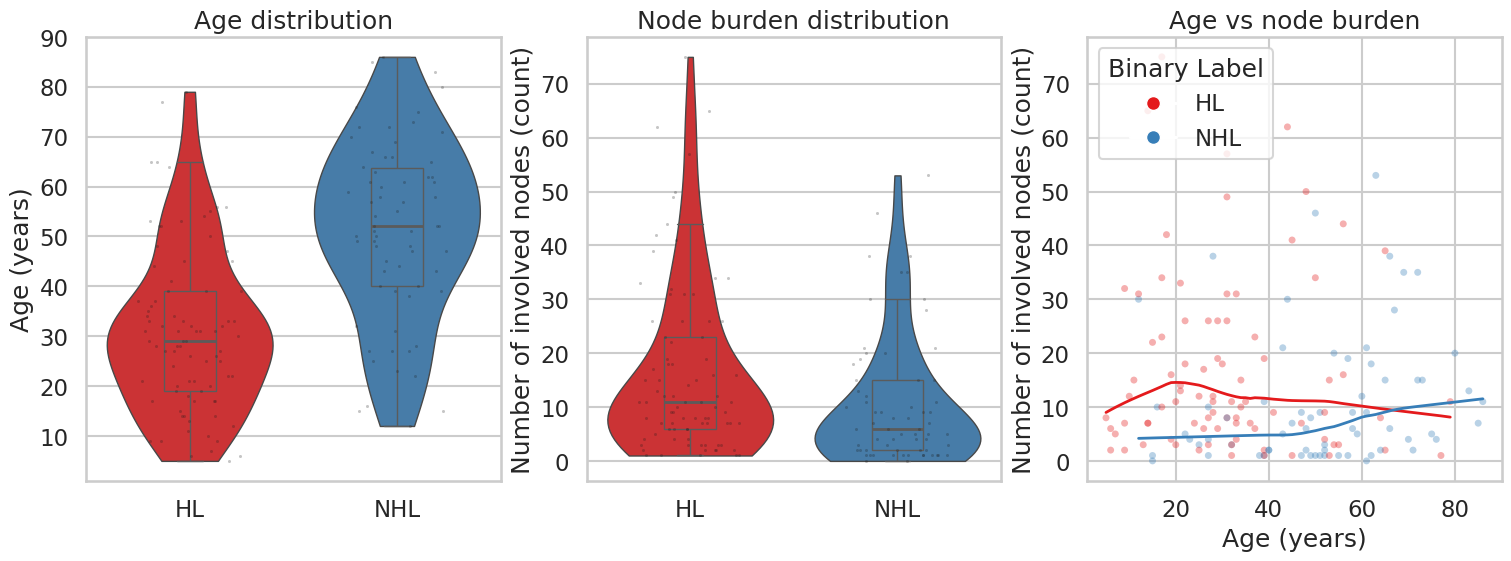

/tmp/ipykernel_2568541/813229708.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2568541/813229708.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


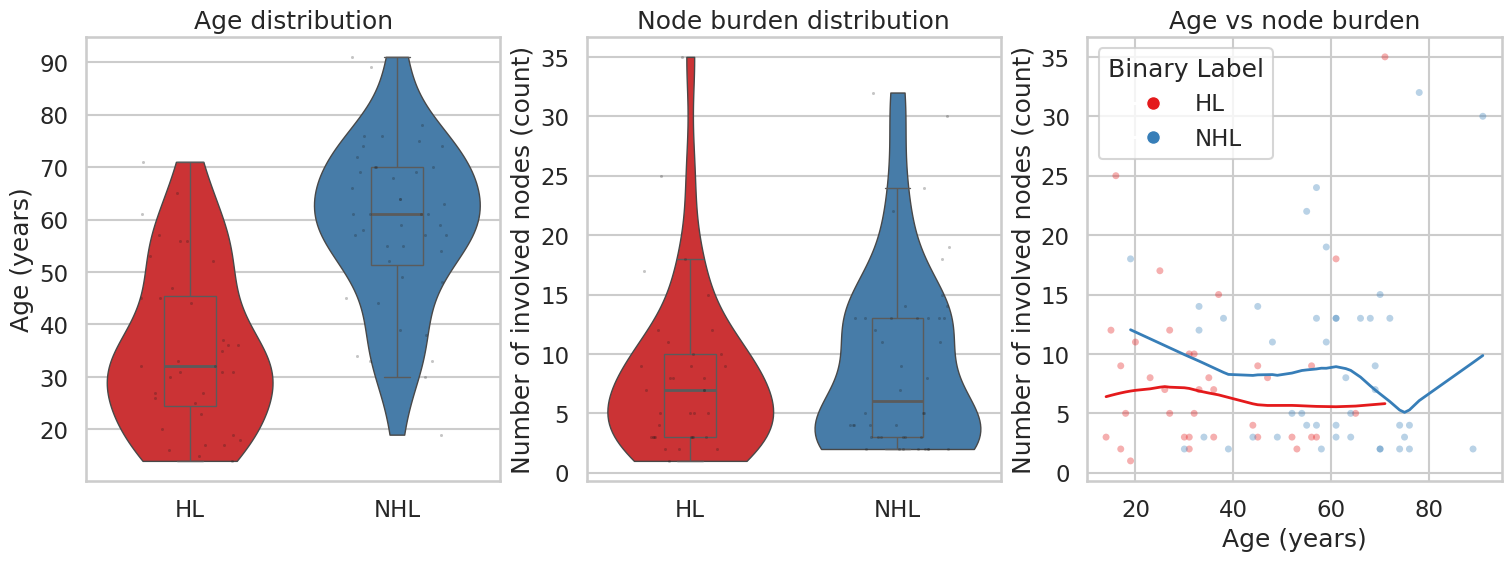

/tmp/ipykernel_2568541/813229708.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2568541/813229708.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


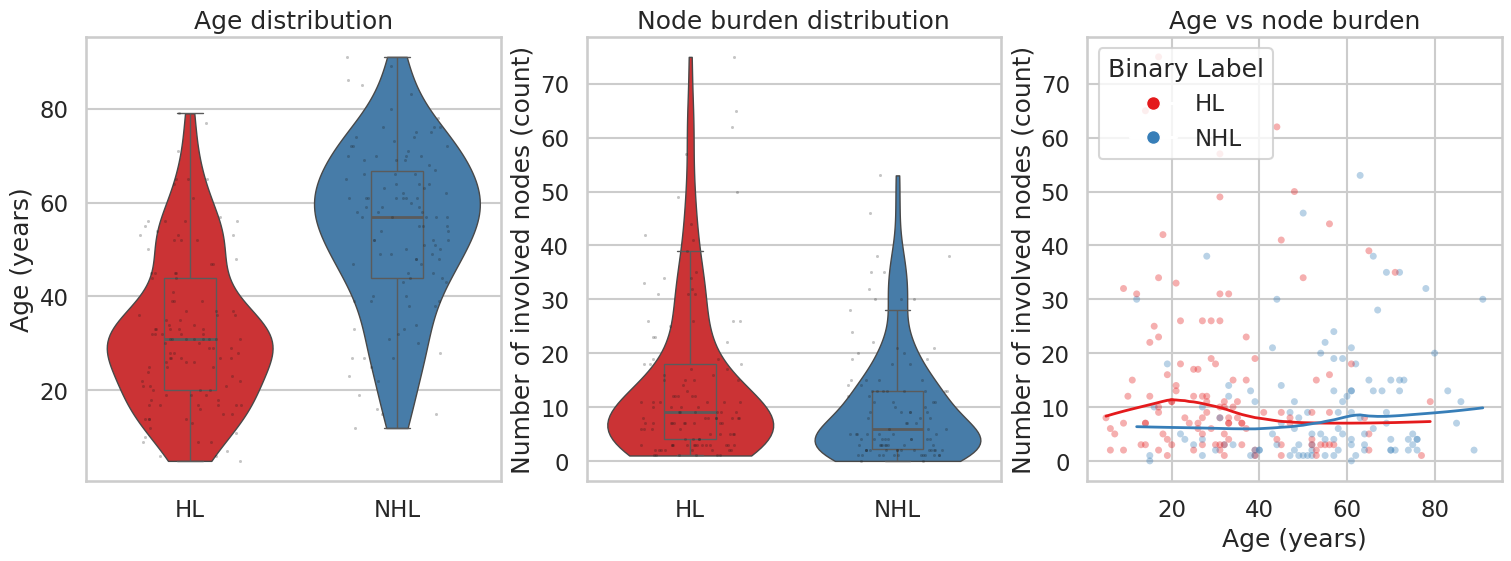

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# def plot_2x2_summary(df, title=None, save_path=None, dpi=300):

#     hue_col = "Binary Label"
#     age_col = "Age"
#     gender_col = "Gender"
#     lesion_col = "Number of involved nodes (count)"

#     df = df.rename(columns={"lesion_count": "Number of involved nodes (count)", "Gender(Male:0, Female:1)": "Gender"})
#     # Define a fixed palette so colors are consistent everywhere
#     # (edit order if your labels are ["NHL","HL"] in the dataframe)
#     hue_order = ["HL", "NHL"]
#     palette = dict(zip(hue_order, sns.color_palette("Set1", n_colors=len(hue_order))))

#     sns.set_context("talk")
#     fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

#     # TOP-LEFT: KDE Age vs Gender (NO per-axis legend)
#     sns.kdeplot(
#         data=df, x=age_col, y=gender_col, hue=hue_col,
#         hue_order=hue_order, palette=palette,
#         fill=True, alpha=0.35, common_norm=False, levels=8,
#         legend=False, ax=axes[0, 0]
#     )
#     # axes[0, 0].set_title("Age vs Gender")
#     axes[0, 0].set_yticks([0, 1])
#     # axes[0, 0].set_yticklabels(["Male (0)", "Female (1)"])
#     axes[0, 0].set_ylim(-0.5, 1.5)

#     # TOP-RIGHT: Violin lesion_count (no legend anyway)
#     sns.violinplot(
#         data=df, x=hue_col, y=lesion_col,
#         order=hue_order, palette=palette,
#         inner="quartile", cut=0, linewidth=1,
#         ax=axes[0, 1]
#     )
#     sns.stripplot(
#         data=df, x=hue_col, y=lesion_col,
#         order=hue_order,
#         color="k", size=2.5, alpha=0.25, jitter=0.25,
#         ax=axes[0, 1]
#     )
#     # axes[0, 1].set_title("Lesion count distribution")

#     # BOTTOM-LEFT: KDE Age vs lesion_count (NO per-axis legend)
#     sns.kdeplot(
#         data=df, x=age_col, y=lesion_col, hue=hue_col,
#         hue_order=hue_order, palette=palette,
#         fill=True, alpha=0.35, common_norm=False, levels=8,
#         legend=False, ax=axes[1, 0]
#     )
#     # axes[1, 0].set_title("Age vs lesion count")

#     # BOTTOM-RIGHT: KDE Gender vs lesion_count (NO per-axis legend)
#     sns.kdeplot(
#         data=df, x=gender_col, y=lesion_col, hue=hue_col,
#         hue_order=hue_order, palette=palette,
#         fill=True, alpha=0.35, common_norm=False, levels=8,
#         legend=False, ax=axes[1, 1]
#     )
#     # axes[1, 1].set_title("Gender vs lesion count")
#     axes[1, 1].set_xlim(-0.5, 1.5)
#     axes[1, 1].set_xticks([0, 1])
#     # axes[1, 1].set_xticklabels(["Male (0)", "Female (1)"])

#     # ---- ONE figure-level legend ----
#     handles = [Patch(facecolor=palette[k], edgecolor="black", label=k) for k in hue_order]
#     fig.legend(handles=handles, title="Binary Label", loc="lower right",  bbox_to_anchor=(1, 0.86), frameon=True)

#     # if title is not None:
#         # fig.suptitle(title, y=1.02, fontsize=16)

#     if save_path is not None:
#         fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    # plt.show()

import numpy as np

def plot_2x2_summary(
    df,
    title=None,
    save_path=None,
    dpi=300,
    hue_col="Binary Label",
    age_col="Age",
    gender_col="Gender(Male:0, Female:1)",
    lesion_col="lesion_count",
    hue_order=("HL", "NHL"),
    log_lesion=False,          # recommended (node counts are skewed)
    add_stats=False,           # annotate n and medians
    point_alpha=0.25,
    point_size=2.2
):
    """
    Publication-style cohort figure for HL vs NHL.
    Panels:
      (A) Age distribution by subtype (violin + box + points)
      (B) Sex composition by subtype (100% stacked bar)
      (C) Node count distribution by subtype (violin + box + points; optional log)
      (D) Age vs node count (scatter + LOWESS trend; optional log)
    """

    df = df.copy()

    # ---- Harmonize columns / names ----
    if gender_col in df.columns:
        df = df.rename(columns={gender_col: "Gender"})
    else:
        # If user already renamed earlier
        if "Gender" not in df.columns:
            raise ValueError(f"Could not find gender column '{gender_col}' or 'Gender' in df.")
    if lesion_col in df.columns:
        df = df.rename(columns={lesion_col: "NodeCount"})
    else:
        if "NodeCount" not in df.columns:
            raise ValueError(f"Could not find lesion/node column '{lesion_col}' or 'NodeCount' in df.")

    # Clean basic types
    df = df.dropna(subset=[hue_col, age_col, "Gender", "NodeCount"]).copy()
    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
    df["NodeCount"] = pd.to_numeric(df["NodeCount"], errors="coerce")
    df["Gender"] = pd.to_numeric(df["Gender"], errors="coerce")
    df = df.dropna(subset=[age_col, "NodeCount", "Gender"])

    # Map gender values to labels for plotting
    gender_map = {0: "Male", 1: "Female"}
    df["GenderLabel"] = df["Gender"].round().astype(int).map(gender_map).fillna("Other/Unknown")

    # Optional log transform for node counts (skewed distributions)
    if log_lesion:
        df["NodeCountPlot"] = np.log1p(df["NodeCount"])
        ylab_nodes = "Number of involved nodes (log1p)"
    else:
        df["NodeCountPlot"] = df["NodeCount"]
        ylab_nodes = "Number of involved nodes (count)"

    # ---- Style ----
    sns.set_theme(style="whitegrid", context="talk")
    palette = dict(zip(hue_order, sns.color_palette("Set1", n_colors=len(hue_order))))

    fig, axes = plt.subplots(1, 3, figsize=(15,5.5), constrained_layout=True)
    axA, axC, axD = axes[0], axes[1], axes[2]

    # ========== (A) Age distribution ==========
    sns.violinplot(
        data=df, x=hue_col, y=age_col, order=hue_order,
        palette=palette, cut=0, inner=None, linewidth=1, ax=axA
    )
    sns.boxplot(
        data=df, x=hue_col, y=age_col, order=hue_order,
        width=0.25, showcaps=True, boxprops={"facecolor":"none"},
        showfliers=False, whiskerprops={"linewidth":1}, medianprops={"linewidth":2},
        ax=axA
    )
    sns.stripplot(
        data=df, x=hue_col, y=age_col, order=hue_order,
        color="k", alpha=point_alpha, size=point_size, jitter=0.25, ax=axA
    )
    axA.set_xlabel("")
    axA.set_ylabel("Age (years)")
    axA.set_title("Age distribution")

    # ========== (B) Sex composition (100% stacked bar) ==========
    # Build percentage table
    # sex_tab = (
    #     df[df[hue_col].isin(hue_order)]
    #     .groupby([hue_col, "GenderLabel"])
    #     .size()
    #     .unstack(fill_value=0)
    #     .reindex(index=list(hue_order))
    # )
    # sex_pct = sex_tab.div(sex_tab.sum(axis=1), axis=0) * 100

    # # Plot stacked bar
    # bottom = np.zeros(len(sex_pct))
    # x = np.arange(len(sex_pct.index))
    # # consistent order
    # gender_levels = [g for g in ["Male", "Female", "Other/Unknown"] if g in sex_pct.columns]
    # for g in gender_levels:
    #     axB.bar(x, sex_pct[g].values, bottom=bottom, edgecolor="black", linewidth=0.8, label=g)
    #     bottom += sex_pct[g].values

    # axB.set_xticks(x)
    # axB.set_xticklabels(list(hue_order))
    # axB.set_ylim(0, 100)
    # axB.set_ylabel("Sex composition (%)")
    # axB.set_xlabel("")
    # axB.set_title("Sex composition")
    # axB.legend(title="Sex", frameon=True, loc="upper right")

    # ========== (C) Node count distribution ==========
    sns.violinplot(
        data=df, x=hue_col, y="NodeCountPlot", order=hue_order,
        palette=palette, cut=0, inner=None, linewidth=1, ax=axC
    )
    sns.boxplot(
        data=df, x=hue_col, y="NodeCountPlot", order=hue_order,
        width=0.25, showcaps=True, boxprops={"facecolor":"none"},
        showfliers=False, whiskerprops={"linewidth":1}, medianprops={"linewidth":2},
        ax=axC
    )
    sns.stripplot(
        data=df, x=hue_col, y="NodeCountPlot", order=hue_order,
        color="k", alpha=point_alpha, size=point_size, jitter=0.25, ax=axC
    )
    axC.set_xlabel("")
    axC.set_ylabel(ylab_nodes)
    axC.set_title("Node burden distribution")

    # ========== (D) Age vs node count ==========
    # Scatter + LOWESS trend per label
    sns.scatterplot(
        data=df, x=age_col, y="NodeCountPlot", hue=hue_col, hue_order=hue_order,
        palette=palette, alpha=0.35, s=25, edgecolor="none", ax=axD, legend=False
    )
    for lab in hue_order:
        dsub = df[df[hue_col] == lab]
        if len(dsub) >= 10:
            sns.regplot(
                data=dsub, x=age_col, y="NodeCountPlot",
                scatter=False, lowess=True, color=palette[lab],
                line_kws={"linewidth":2}, ax=axD
            )

    axD.set_xlabel("Age (years)")
    axD.set_ylabel(ylab_nodes)
    axD.set_title("Age vs node burden")

    # ---- Add compact statistics annotations (n + medians/IQR) ----
    if add_stats:
        def med_iqr(x):
            q1, q2, q3 = np.percentile(x, [25, 50, 75])
            return q2, q1, q3

        # For age + node count stats (use raw node count for interpretability)
        lines = []
        for lab in hue_order:
            sub = df[df[hue_col] == lab]
            n = len(sub)
            age_med, age_q1, age_q3 = med_iqr(sub[age_col].values)
            nc_med, nc_q1, nc_q3 = med_iqr(sub["NodeCount"].values)
            lines.append(
                f"{lab}: n={n} | Age {age_med:.0f}[{age_q1:.0f}-{age_q3:.0f}] | Nodes {nc_med:.0f}[{nc_q1:.0f}-{nc_q3:.0f}]"
            )

        fig.text(
            0.01, 0.01,
            "  •  ".join(lines),
            ha="left", va="bottom", fontsize=11
        )

    # ---- One clean legend for HL/NHL (only once) ----
    # Put it in the empty space: top-left inside D, or outside if you prefer.
    handles = [plt.Line2D([0],[0], marker="o", color="w",
                          markerfacecolor=palette[k], markersize=10, label=k)
               for k in hue_order]
    axD.legend(handles=handles, title="Binary Label", frameon=True, loc="upper left")

    # if title:
    #     fig.suptitle(title, y=1.02, fontsize=16)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

# Usage (same as your previous calls)
plot_2x2_summary(center_1_df, title="Center 1", save_path="figures/center1_2x2.png")
plot_2x2_summary(center_2_df, title="Center 2", save_path="figures/center2_2x2.png")
plot_2x2_summary(combined_centers_df, title="Combined", save_path="figures/combined_2x2.png")